In [6]:
import pandas as pd

train_df = pd.read_csv("new_train_balanced.csv")
val_df = pd.read_csv("new_val.csv")
test_df = pd.read_csv("new_test.csv")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(13005, 2) (1626, 2) (1626, 2)


,clean_text,label
0,واشنطن تكشف امام مجلس_الامن اسماء ضباط سورين م...,2
1,اليمن مجزره_القاعه_الكبري احمدوا اله كثيرا واش...,2
2,المراه السعوديه ماجوره علي انواع المعاناه والظ...,1
3,سعوديات_نطلب_اسقاط_الولايه\n الحياه من حق المر...,1
4,RT عبد الرحمن الراشد في مقالته يكتب عن حضوره ح...,1


فصل X و y

In [7]:
X_train = train_df['clean_text']
y_train = train_df['label']

X_val = val_df['clean_text']
y_val = val_df['label']

X_test = test_df['clean_text']
y_test = test_df['label']

 ### تطبيق TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,   # أهم 10k كلمة
    ngram_range=(1,2),    # unigram + bigram
    min_df=3              # تجاهل الكلمات النادرة جدًا
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(13005, 10000)


max_features=10000 → يقلل noise

ngram_range=(1,2) → يفهم “مو حلو” كعبارة

min_df=3 → يحذف الكلمات النادرة مره

 تجربة أول مودل (Baseline)

### خلينا نبدأ بـ Logistic Regression 

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [11]:
model.fit(X_train_tfidf, y_train)

print("Model trained ")

Model trained 


In [12]:
y_val_pred = model.predict(X_val_tfidf)  #التنبؤ على Validation

In [13]:
#تقييم Validation

from sklearn.metrics import classification_report, accuracy_score

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.6642066420664207

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.70      0.68       629
           1       0.76      0.66      0.71       786
           2       0.43      0.56      0.49       211

    accuracy                           0.66      1626
   macro avg       0.62      0.64      0.63      1626
weighted avg       0.68      0.66      0.67      1626



In [14]:
y_test_pred = model.predict(X_test_tfidf) #التنبؤ على Test

In [15]:
# تقييم Test
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.6734317343173432

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.67      0.72      0.69       630
           1       0.74      0.66      0.70       786
           2       0.49      0.60      0.54       210

    accuracy                           0.67      1626
   macro avg       0.63      0.66      0.64      1626
weighted avg       0.68      0.67      0.68      1626



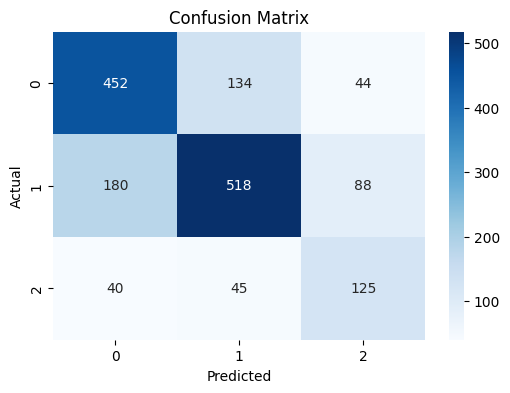

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### تجربة (Support Vector Machine - SVM)

In [20]:
from sklearn.svm import LinearSVC
model = LinearSVC()

In [21]:
model.fit(X_train_tfidf, y_train)

print("SVM trained ")

SVM trained 


التنبؤ

In [22]:
y_val_pred = model.predict(X_val_tfidf)
y_test_pred = model.predict(X_test_tfidf)

التقييم

In [23]:
from sklearn.metrics import classification_report, accuracy_score

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Validation Accuracy: 0.6451414514145142
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       629
           1       0.72      0.66      0.69       786
           2       0.43      0.47      0.45       211

    accuracy                           0.65      1626
   macro avg       0.60      0.61      0.60      1626
weighted avg       0.65      0.65      0.65      1626


Test Accuracy: 0.6377613776137762
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       630
           1       0.70      0.66      0.68       786
           2       0.44      0.47      0.45       210

    accuracy                           0.64      1626
   macro avg       0.59      0.60      0.59      1626
weighted avg       0.64      0.64      0.64      1626



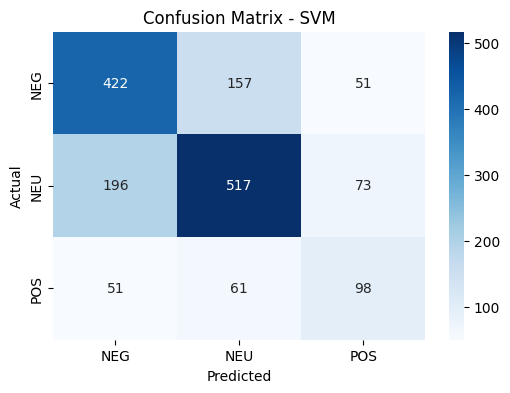

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NEG', 'NEU', 'POS'],
    yticklabels=['NEG', 'NEU', 'POS']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

### AraBERT مودل